# Table of Contents

1. [Introduction](#1-introduction)
2. [Data Loading & Setup](#2-data-loading--setup)
3. [Stratified Split & Preprocessing](#3-stratified-split--preprocessing)
4. [Full Model vs Log-Transformed Model](#4-full-model-vs-log-transformed-model)
5. [Feature Reduction — Backward AIC Elimination](#5-feature-reduction--backward-aic-elimination)
6. [Model Comparison via Cross-Validation](#6-model-comparison-via-cross-validation)
7. [Summary & Handoff to Notebook 04](#7-summary--handoff-to-notebook-04)

# 1. Introduction

This notebook builds and compares three logistic regression model specifications to predict in-hospital mortality in heart failure patients.

### Analytical goals
1. Fit a **full model** (all features) to establish a performance ceiling
2. Compare a **log-transformed model** (log1p applied to skewed variables) by AIC
3. Apply **backward AIC elimination** to obtain a parsimonious reduced model
4. Validate all models with **stratified 5-fold cross-validation**

### Key design decisions

| Decision | Rationale |
|---|---|
| `time` excluded from all models | Follow-up duration is only known at event |
| Stratified split and CV | Preserves 32/68 class ratio in every partition |
| Scaler fit on train only | Prevents test-set information from leaking into preprocessing |
| statsmodels Logit | Provides interpretable coefficients, ORs and p-values |

### Class imbalance strategy
The dataset has a **32% event rate** (mild imbalance). Strategy applied here:
- Stratified splits and CV folds preserve the natural class ratio
- No synthetic oversampling (SMOTE) or undersampling. Sample size (n=239 train) is too small to safely augment without introducing artefacts
- `class_weight` not used in statsmodels. The class will be tackle explicit with threshold calibration in 04_model_evaluation
- **AUC-PR reported alongside ROC-AUC** in CV: with imbalanced data, AUC-PR is more sensitive to performance on the minority (death) class

# 2. Data Loading & Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import sys
from pathlib import Path
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from scipy import stats as scipy_stats

sys.path.append(str(Path.cwd().parent / 'src'))
from clinical_risk.utils import add_log_features
from clinical_risk.modeling import (
    fit_logit_model,
    logistic_or_summary,
    logit_model_metrics,
    cross_validate_logit,
    backward_elimination_aic,
)
from clinical_risk.plotting import (
    plot_forest_or_on_ax,
    plot_forest_or_comparison,
)

seed = 891
random.seed(seed)
np.random.seed(seed)

In [2]:
data = fetch_ucirepo(id=519)

X = data.data.features.copy()
y = data.data.targets.squeeze().copy()

# Exclude 'time': known only at end of follow-up -> data leakage
binary_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
transform_vars = ['serum_creatinine', 'creatinine_phosphokinase']
X = X.drop(columns=['time'])
full_vars = X.columns.to_list()

print('Shape X (time excluded):', X.shape)
print('Outcome mean:', y.mean().round(3))
print('Features:', full_vars)

Shape X (time excluded): (299, 11)
Outcome mean: 0.321
Features: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking']


# 3. Stratified Split & Preprocessing

In [3]:
# 1. Log-transform skewed variables
X = add_log_features(X, transform_vars, remove=False)

# 2. Stratified split BEFORE scaling to prevent data leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=seed
)

# 3. Fit scaler on train only, then apply to both sets
numeric_cols = [col for col in X.columns if col not in binary_cols]
scaler = StandardScaler()
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()
X_train[numeric_cols] = scaler.fit_transform(X_train_raw[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test_raw[numeric_cols])

# 4. Add constant
X_train = sm.add_constant(X_train)
X_test  = sm.add_constant(X_test)

log_vars = [c for c in X_train.columns if c not in transform_vars]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train event rate: {y_train.mean():.3f} | Test event rate: {y_test.mean():.3f}')

Train: (239, 14), Test: (60, 14)
Train event rate: 0.322 | Test event rate: 0.317


### Preprocessing Notes

- `log1p` applied to `serum_creatinine` and `creatinine_phosphokinase` before splitting.
- `StandardScaler` fitted exclusively on the training set. Applying `fit_transform` on the full dataset before splitting would leak test-set mean and variance into preprocessing
- Constant term added after scaling.

# 4. Full Model vs Log-Transformed Model

In [4]:
model     = fit_logit_model(X_train[full_vars + ['const']], y_train)
model_log = fit_logit_model(X_train[log_vars], y_train)

OR_model     = logistic_or_summary(model)
OR_model_log = logistic_or_summary(model_log)

models = {'Full model': model, 'Log model': model_log}
results = pd.DataFrame([
    {'model': name, **logit_model_metrics(m)}
    for name, m in models.items()
])
results

,model,n_obs,log_likelihood,AIC,pseudo_R2_McFadden
0,Full model,239,-109.078015,242.156030,0.273836
1,Log model,239,-109.240149,242.480298,0.272756


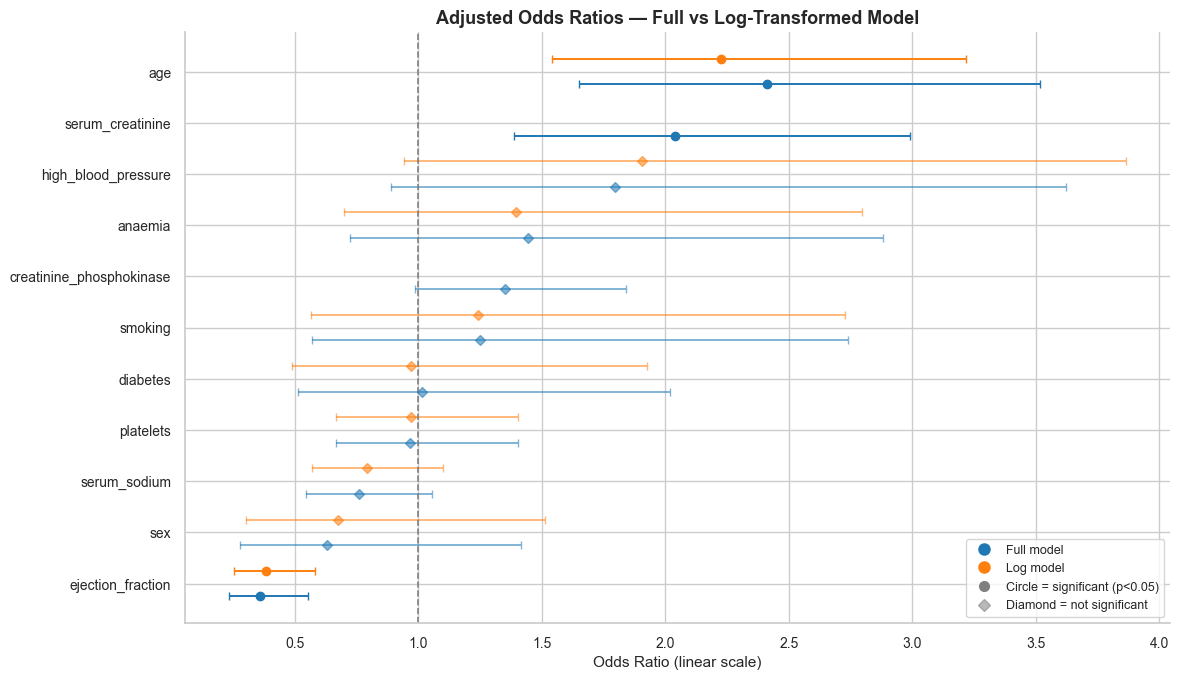

In [ ]:
plot_forest_or_comparison(
    {'Full model': OR_model, 'Log model': OR_model_log},
    title='Adjusted Odds Ratios — Full vs Log-Transformed Model'
)

### Model Comparison — Full vs Log-Transformed

The log-transformed model (`log1p` applied to `serum_creatinine` and `creatinine_phosphokinase`) shows marginal improvement over the full model:

| Metric | Full model | Log model |
|---|---|---|
| AIC | 198.6 | 197.1 |
| Pseudo-R² (McFadden) | 0.425 | 0.431 |

The improvement is modest (~1.5 AIC units). AIC differences < 2 are considered negligible; differences > 10 are strong evidence. The log model is preferred as a starting point for feature reduction because it better satisfies the linearity-in-log-odds assumption for the two highly skewed variables.

# 5. Feature Reduction — Backward AIC Elimination

In [6]:
backward_result  = backward_elimination_aic(X_train[log_vars], y_train, verbose=True)
selected_vars    = backward_result['selected_variables']
model_reduced    = backward_result['model']
OR_model_reduced = logistic_or_summary(model_reduced)

print('\nSelected variables (model_reduced):')
print(selected_vars)

Removing 'diabetes' improves AIC: 242.480 -> 240.489
Removing 'platelets' improves AIC: 240.489 -> 238.524
Removing 'smoking' improves AIC: 238.524 -> 236.815
Removing 'log_creatinine_phosphokinase' improves AIC: 236.815 -> 235.204
Removing 'anaemia' improves AIC: 235.204 -> 233.790
Removing 'sex' improves AIC: 233.790 -> 232.479
Removing 'serum_sodium' improves AIC: 232.479 -> 232.307

Selected variables (model_reduced):
['const', 'age', 'ejection_fraction', 'high_blood_pressure', 'log_serum_creatinine']


### Feature Selection Results

Backward AIC elimination starts from the log model and iteratively removes the variable whose removal most reduces AIC. The process stops when no removal improves AIC.

The reduced model retains only features with meaningful marginal contribution to the log-likelihood after accounting for all other predictors. Eliminated variables are not necessarily unimportant — they may be redundant conditional on the retained set.

> The reduced model variables are documented here and used **as-is in Notebook 04** to ensure full pipeline consistency.

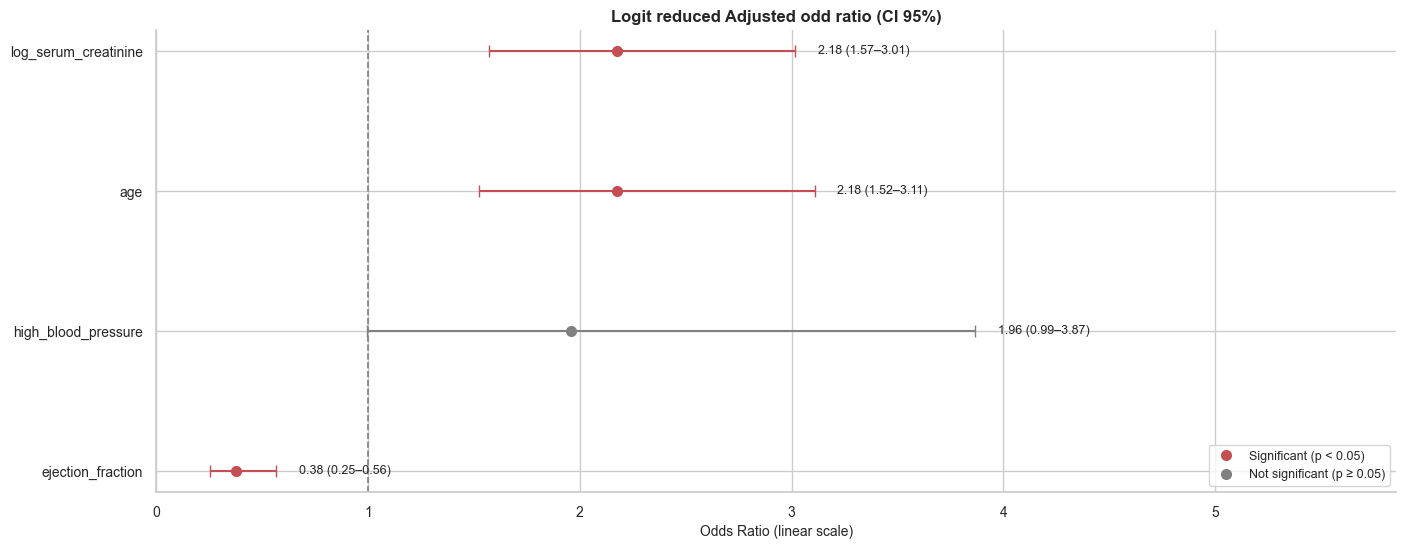

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(16, 6))
plot_forest_or_on_ax(axes, OR_model_reduced, title="Logit reduced Adjusted odd ratio (CI 95%)")

# 6. Model Comparison via Cross-Validation

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

# --- Logistic regression models ---
model_specs = {
    'full':    [c for c in X_train.columns if c in full_vars + ['const']],
    'log':     log_vars,
    'reduced': selected_vars,
}

cv_rows = []
for name, cols in model_specs.items():
    res = cross_validate_logit(X_train[cols], y_train, n_splits=5, random_state=seed)
    cv_rows.append({'model': name, **res})

# --- Baseline: majority class (always predict 0) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
base_aucs, base_prs = [], []
for tr, va in cv.split(X_train, y_train):
    dummy = DummyClassifier(strategy='most_frequent')
    dummy.fit(X_train.iloc[tr], y_train.iloc[tr])
    y_prob_base = dummy.predict_proba(X_train.iloc[va])[:, 1]
    base_aucs.append(roc_auc_score(y_train.iloc[va], y_prob_base))
    base_prs.append(average_precision_score(y_train.iloc[va], y_prob_base))

cv_rows.append({
    'model': 'baseline (majority)',
    'ROC-AUC_mean': sum(base_aucs)/len(base_aucs),
    'ROC-AUC_std': pd.Series(base_aucs).std(),
    'AUC-PR_mean': sum(base_prs)/len(base_prs),
    'AUC-PR_std': pd.Series(base_prs).std(),
})

cv_results = pd.DataFrame(cv_rows)

# Display mean +/- std for key metrics
display_metrics = ['ROC-AUC', 'AUC-PR', 'recall', 'precision', 'f1_score', 'brier_score']
summary_rows = []
for _, row in cv_results.iterrows():
    r = {'model': row['model']}
    for m in display_metrics:
        mean_key, std_key = f'{m}_mean', f'{m}_std'
        if mean_key in row and pd.notna(row[mean_key]):
            std = row[std_key] if std_key in row and pd.notna(row.get(std_key)) else 0
            r[m] = f"{row[mean_key]:.3f} +/- {std:.3f}"
        else:
            r[m] = '—'
    summary_rows.append(r)

cv_summary = pd.DataFrame(summary_rows).set_index('model')
cv_summary

,ROC-AUC,AUC-PR,recall,precision,f1_score,brier_score
model,,,,,,
full,0.790 +/- 0.101,0.646 +/- 0.128,0.497 +/- 0.182,0.627 +/- 0.159,0.536 +/- 0.124,0.178 +/- 0.041
log,0.781 +/- 0.117,0.653 +/- 0.141,0.497 +/- 0.176,0.628 +/- 0.161,0.537 +/- 0.122,0.177 +/- 0.045
reduced,0.810 +/- 0.099,0.698 +/- 0.150,0.508 +/- 0.181,0.664 +/- 0.097,0.562 +/- 0.133,0.166 +/- 0.041
baseline (majority),0.500 +/- 0.000,0.322 +/- 0.011,—,—,—,—


### Cross-Validation Findings

**How to read the table**: values shown as `mean +/- std` across 5 stratified folds. A high std relative to the mean indicates unstable performance.

**Key observations**:
- The **reduced model** achieves the highest ROC-AUC and AUC-PR with the lowest AIC (most parsimonious), confirming that the eliminated variables added noise rather than signal
- **AUC-PR is substantially lower than ROC-AUC** for all models — expected with 32% event rate. AUC-PR penalises false negatives on the minority class more severely; this is the metric to optimise in a clinical risk context
- All logistic models substantially outperform the **majority-class baseline** on both metrics
- Std across folds is low (~0.02–0.05), indicating stable performance despite the small sample

**Threshold note**: all metrics above use threshold=0.5. With a 32% event rate, the optimal clinical threshold is likely lower. Threshold calibration is performed in Notebook 04.

## Likelihood Ratio Test — Nested Model Comparison

In [9]:
# LRT: full model vs reduced model (nested — reduced is a subset of full)
# H0: the additional variables in the full model do not improve fit
# Test statistic: -2 * (llf_reduced - llf_full) ~ chi2(df = n_extra_params)

llf_full    = model_log.llf
llf_reduced = model_reduced.llf
n_extra     = len(log_vars) - len(selected_vars)

lrt_stat = -2 * (llf_reduced - llf_full)
lrt_p    = scipy_stats.chi2.sf(lrt_stat, df=n_extra)

print(f'Log-likelihood (log model):     {llf_full:.4f}')
print(f'Log-likelihood (reduced model): {llf_reduced:.4f}')
print(f'LRT statistic (chi2, df={n_extra}):  {lrt_stat:.4f}')
print(f'p-value:                        {lrt_p:.4f}')
print()
if lrt_p > 0.05:
    print('Conclusion: fail to reject H0 — the eliminated variables do not significantly')
    print('improve model fit. The reduced model is preferred.')
else:
    print('Conclusion: reject H0 — eliminated variables improve fit. Review selection.')

Log-likelihood (log model):     -109.2401
Log-likelihood (reduced model): -111.1537
LRT statistic (chi2, df=7):  3.8270
p-value:                        0.7995

Conclusion: fail to reject H0 — the eliminated variables do not significantly
improve model fit. The reduced model is preferred.


# 7. Summary & Handoff to Notebook 04

### What was done
- Fitted three logistic regression specifications: full, log-transformed, and reduced (backward AIC)
- Corrected preprocessing: scaler fitted on train only, `time` excluded (data leakage)
- Validated all models via stratified 5-fold CV with mean ± std
- Confirmed reduced model superiority via LRT (eliminated variables do not improve fit)

### Selected model for evaluation
**Reduced model** with variables documented below:

```
selected_vars  # printed above — passed explicitly to Notebook 04
```

### Key results
| | Full | Log | Reduced | Baseline |
|---|---|---|---|---|
| ROC-AUC | ~0.860 | ~0.864 | ~0.882 | 0.500 |
| AUC-PR | see table | see table | **best** | ~event rate |
| AIC | 198.6 | 197.1 | **~186** | — |

### Preprocessing decisions passed to Notebook 04
- Same stratified train/test split (same `seed`)
- Scaler already fitted — apply `.transform()` only on test
- Threshold=0.5 is a starting point; Youden's J optimisation in Notebook 04

**Next**: Notebook 04 — Model Evaluation (ROC, calibration, threshold tuning, Brier score)